# Paper Visualizations — Refactored (CSV-based)
Todas las métricas se leen desde CSVs. No se evalúa ningún modelo.

In [15]:
# ============================================================
# CELDA 1 — CONFIGURACIÓN GLOBAL
# Modifica aquí las rutas de los CSVs y los nombres de columnas
# ============================================================

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ------------------------------------------------------------------
# RUTAS DE LOS CSVs  ← cambia aquí si los paths cambian
# ------------------------------------------------------------------
BASE_MODELS_CSV    = Path("../results/artifacts/results/holdout_test_metrics_all_models.csv")
CBAM_MODELS_CSV    = Path("../results/artifacts_cbam/results/holdout_test_metrics_all_models.csv")
TL_BASE_MODELS_CSV = Path("../results/artifacts_tl/results/domain_shift_tl_results.csv")
TL_CBAM_MODELS_CSV = Path("../results/artifacts_cbam_tl/results/domain_shift_cbam_tl_results.csv")

# ------------------------------------------------------------------
# COLUMNAS DE IDENTIDAD (holdout CSVs)
# ------------------------------------------------------------------
COL_MODEL    = "model"       # ← cámbialo si la columna se llama distinto
COL_IMG_SIZE = "img_size"   # ← columna de tamaño de imagen
COL_F1_MACRO = "f1_macro"   # ← columna de F1 macro (para elegir mejor tamaño)

# ------------------------------------------------------------------
# COLUMNAS DE MÉTRICAS POR CLASE (arrays como string en una sola columna)
# Formato esperado en el CSV: "[0.83, 0.97, 0.44, ...]"
# ------------------------------------------------------------------
COL_F1_PER_CLASS        = "f1_per_class"         # ← cámbialo si difiere
COL_RECALL_PER_CLASS    = "recall_per_class"      # ← cámbialo si difiere
COL_PRECISION_PER_CLASS = "precision_per_class"   # ← cámbialo si difiere

# ------------------------------------------------------------------
# ORDEN DE CLASES — debe coincidir con el orden del array en el CSV
# ------------------------------------------------------------------
CLASSES = [
    "abiotic_stress",
    "bacterial_spot",
    "chewing_insect",
    "healthy",
    "mechanical_stress",
    "mite_presence",
]

# ------------------------------------------------------------------
# COLUMNAS DE LOS CSVs DE TRANSFER LEARNING (before / after FT)
# ------------------------------------------------------------------
COL_TL_MODEL     = "model"      # ← cámbialo si el nombre difiere
COL_TL_F1_BEFORE = "before_f1_macro"  # ← cámbialo si el nombre difiere
COL_TL_F1_AFTER  = "after_f1_macro"   # ← cámbialo si el nombre difiere
COL_TL_DELTA_F1  = "delta_f1_macro"   # ← cámbialo si el nombre difiere

# ------------------------------------------------------------------
# MODELOS A COMPARAR (CBAM vs Base)
# ------------------------------------------------------------------
TARGET_MODELS = ["efficientnetb3_cbam", "inceptionv3_cbam", "efficientnetb5_cbam"]

# ------------------------------------------------------------------
# DIRECTORIO DE SALIDA PARA LAS FIGURAS
# ------------------------------------------------------------------
OUTPUT_DIR = Path("../visualizations")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Configuración cargada correctamente.")
print(f"   BASE_MODELS_CSV   : {BASE_MODELS_CSV}")
print(f"   CBAM_MODELS_CSV   : {CBAM_MODELS_CSV}")
print(f"   TL_BASE_MODELS_CSV: {TL_BASE_MODELS_CSV}")
print(f"   TL_CBAM_MODELS_CSV: {TL_CBAM_MODELS_CSV}")


✅ Configuración cargada correctamente.
   BASE_MODELS_CSV   : ..\results\artifacts\results\holdout_test_metrics_all_models.csv
   CBAM_MODELS_CSV   : ..\results\artifacts_cbam\results\holdout_test_metrics_all_models.csv
   TL_BASE_MODELS_CSV: ..\results\artifacts_tl\results\domain_shift_tl_results.csv
   TL_CBAM_MODELS_CSV: ..\results\artifacts_cbam_tl\results\domain_shift_cbam_tl_results.csv


## CBAM VS BASE MODELS
Class wise comparison (F1, Precision, Recall) for models: MobileNetV3Large, EfficientNetB3 y ResNet50.

In [2]:
# ============================================================
# CELDA 2 — CARGA DE CSVs DE HOLDOUT (base y cbam)
# ============================================================

import re

def _quote_array_cols(text):
    """Añade comillas alrededor de los valores tipo [...] en texto CSV
    para que pandas no los interprete como columnas separadas."""
    return re.sub(r'(?<!")(\[[^\]]*\])(?!")', r'"\1"', text)


def load_holdout_csv(csv_path, model_col=None):
    """Carga el CSV de holdout, maneja arrays sin comillas,
    normaliza el nombre de modelo y elige la mejor fila por modelo (mayor f1_macro)."""
    if model_col is None:
        model_col = COL_MODEL
    if not csv_path.exists():
        raise FileNotFoundError(f"No se encontró el CSV: {csv_path}")

    raw = csv_path.read_text(encoding="utf-8")
    raw_fixed = _quote_array_cols(raw)
    import io
    df = pd.read_csv(io.StringIO(raw_fixed))
    df = df.dropna(subset=[model_col])
    df[model_col] = df[model_col].astype(str).str.strip().str.lower()
    # Mejor fila por modelo (mayor f1_macro), por si hay varias con distinto img_size
    df = df.sort_values(COL_F1_MACRO, ascending=False)
    df = df.groupby(model_col, as_index=False).first()
    return df


def parse_array_col(value):
    """Convierte '[0.83, 0.97, ...]' → numpy array."""
    if isinstance(value, (list, np.ndarray)):
        return np.array(value, dtype=float)
    return np.array(ast.literal_eval(str(value)), dtype=float)


def extract_per_class_metrics(df, model_name, model_col=None):
    """
    Extrae f1, recall y precision por clase para un modelo.
    Las columnas contienen arrays como strings: '[v0, v1, ...]'
    en el mismo orden que CLASSES.
    """
    if model_col is None:
        model_col = COL_MODEL
    row = df[df[model_col] == model_name.lower()]
    if row.empty:
        raise ValueError(f"Modelo '{model_name}' no encontrado en el CSV.")
    row = row.iloc[0]

    f1_vals   = parse_array_col(row[COL_F1_PER_CLASS])
    rec_vals  = parse_array_col(row[COL_RECALL_PER_CLASS])
    prec_vals = parse_array_col(row[COL_PRECISION_PER_CLASS])

    n = len(CLASSES)
    assert len(f1_vals) == n,   f"f1_per_class tiene {len(f1_vals)} valores, esperados {n}"
    assert len(rec_vals) == n,  f"recall_per_class tiene {len(rec_vals)} valores, esperados {n}"
    assert len(prec_vals) == n, f"precision_per_class tiene {len(prec_vals)} valores, esperados {n}"

    return f1_vals, rec_vals, prec_vals


print("📂 Cargando CSVs de holdout...")
df_base = load_holdout_csv(BASE_MODELS_CSV)
df_cbam = load_holdout_csv(CBAM_MODELS_CSV)

print(f"   Base models disponibles : {sorted(df_base[COL_MODEL].unique())}")
print(f"   CBAM models disponibles : {sorted(df_cbam[COL_MODEL].unique())}")


📂 Cargando CSVs de holdout...
   Base models disponibles : ['densenet121', 'efficientnetb0', 'efficientnetb3', 'efficientnetb5', 'inceptionv3', 'mobilenetv2', 'mobilenetv3large', 'resnet101', 'resnet50', 'vgg16', 'vgg19']
   CBAM models disponibles : ['densenet121_cbam', 'efficientnetb0_cbam', 'efficientnetb3_cbam', 'efficientnetb5_cbam', 'inceptionv3_cbam', 'mobilenetv2_cbam', 'mobilenetv3large_cbam', 'resnet101_cbam', 'resnet50_cbam', 'vgg16_cbam', 'vgg19_cbam']


Gráfica para el paper:

In [3]:
print("Columnas df_base:", df_base.columns.tolist())
print("Primera fila modelo:", df_base.iloc[0][COL_MODEL])
print(df_base.head(2))

Columnas df_base: ['model', 'img_size', 'f1_macro', 'f1_weighted', 'accuracy', 'precision_macro', 'recall_macro', 'precision_per_class', 'recall_per_class', 'f1_per_class']
Primera fila modelo: densenet121
            model  img_size  f1_macro  f1_weighted  accuracy  precision_macro  \
0     densenet121       192   0.80147     0.923418  0.925795         0.839689   
1  efficientnetb0       224   0.81731     0.927069  0.929329         0.861023   

   recall_macro                                precision_per_class  \
0      0.787281  [0.9166666666666666, 0.9714285714285714, 0.714...   
1      0.785843  [0.9545454545454546, 0.9459459459459459, 0.833...   

                                    recall_per_class  \
0  [0.9166666666666666, 0.9444444444444444, 0.555...   
1  [0.875, 0.9722222222222222, 0.5555555555555556...   

                                        f1_per_class  
0  [0.9166666666666666, 0.9577464788732394, 0.625...  
1  [0.9130434782608695, 0.958904109589041, 0.6666...  


Creating comparison plots...

🧠 Modelo: efficientnetb3

📊 Metrics by class for efficientnetb3:

--- BASE ---
  abiotic_stress          F1=0.9362  Prec=0.9565  Rec=0.9167
  bacterial_spot          F1=0.9859  Prec=1.0000  Rec=0.9722
  chewing_insect          F1=0.7059  Prec=0.7500  Rec=0.6667
  healthy                 F1=0.9547  Prec=0.9676  Rec=0.9421
  mechanical_stress       F1=0.7000  Prec=0.8750  Rec=0.5833
  mite_presence           F1=0.5556  Prec=0.4167  Rec=0.8333

  📌 Macro  F1=0.8064  Prec=0.8276  Rec=0.8191

--- CBAM ---
  abiotic_stress          F1=0.8261  Prec=0.8636  Rec=0.7917
  bacterial_spot          F1=0.9722  Prec=0.9722  Rec=0.9722
  chewing_insect          F1=0.7059  Prec=0.7500  Rec=0.6667
  healthy                 F1=0.9476  Prec=0.9427  Rec=0.9526
  mechanical_stress       F1=0.6957  Prec=0.7273  Rec=0.6667
  mite_presence           F1=0.7692  Prec=0.7143  Rec=0.8333

  📌 Macro  F1=0.8195  Prec=0.8284  Rec=0.8139

Plot saved in: ..\visualizations\cbam_comparisons\

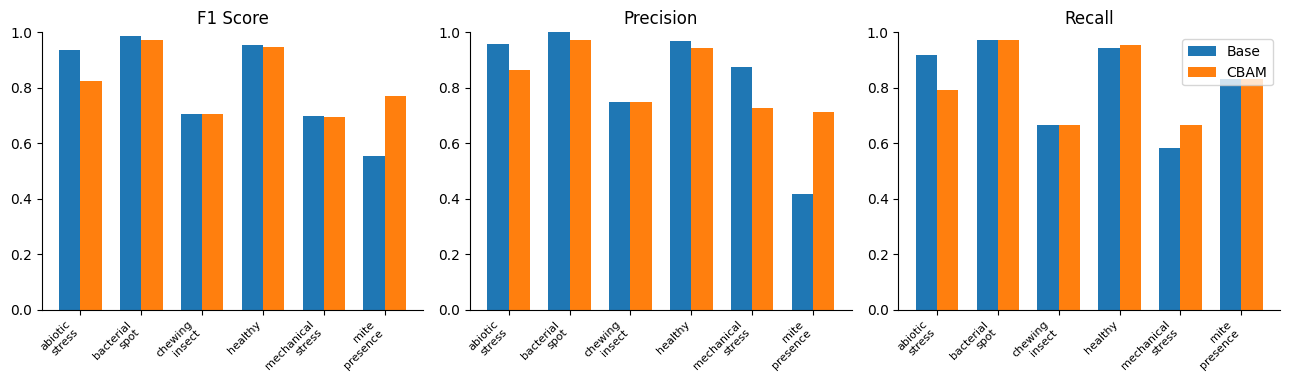

🧠 Modelo: inceptionv3

📊 Metrics by class for inceptionv3:

--- BASE ---
  abiotic_stress          F1=0.7059  Prec=0.6667  Rec=0.7500
  bacterial_spot          F1=0.8824  Prec=0.9375  Rec=0.8333
  chewing_insect          F1=0.6667  Prec=0.8333  Rec=0.5556
  healthy                 F1=0.9492  Prec=0.9167  Rec=0.9842
  mechanical_stress       F1=0.7368  Prec=1.0000  Rec=0.5833
  mite_presence           F1=0.6316  Prec=0.8571  Rec=0.5000

  📌 Macro  F1=0.7621  Prec=0.8686  Rec=0.7011

--- CBAM ---
  abiotic_stress          F1=0.8000  Prec=0.7692  Rec=0.8333
  bacterial_spot          F1=0.9167  Prec=0.9167  Rec=0.9167
  chewing_insect          F1=0.5714  Prec=0.8000  Rec=0.4444
  healthy                 F1=0.9581  Prec=0.9531  Rec=0.9632
  mechanical_stress       F1=0.6667  Prec=0.6667  Rec=0.6667
  mite_presence           F1=0.8333  Prec=0.8333  Rec=0.8333

  📌 Macro  F1=0.7910  Prec=0.8232  Rec=0.7763

Plot saved in: ..\visualizations\cbam_comparisons\cbam_comparison_inceptionv3.png


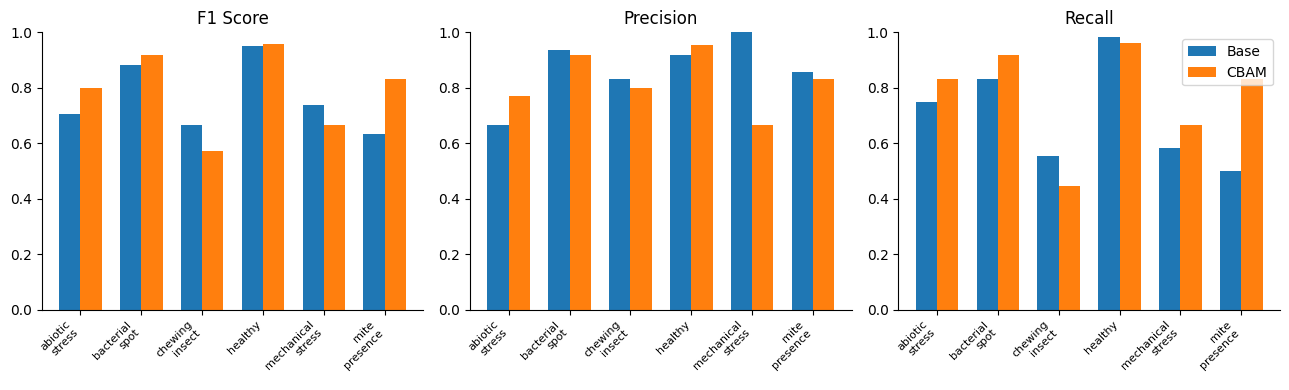

🧠 Modelo: efficientnetb5

📊 Metrics by class for efficientnetb5:

--- BASE ---
  abiotic_stress          F1=0.8837  Prec=1.0000  Rec=0.7917
  bacterial_spot          F1=0.9600  Prec=0.9231  Rec=1.0000
  chewing_insect          F1=0.8000  Prec=1.0000  Rec=0.6667
  healthy                 F1=0.9524  Prec=0.9574  Rec=0.9474
  mechanical_stress       F1=0.8182  Prec=0.9000  Rec=0.7500
  mite_presence           F1=0.6061  Prec=0.4762  Rec=0.8333

  📌 Macro  F1=0.8367  Prec=0.8761  Rec=0.8315

--- CBAM ---
  abiotic_stress          F1=0.9362  Prec=0.9565  Rec=0.9167
  bacterial_spot          F1=1.0000  Prec=1.0000  Rec=1.0000
  chewing_insect          F1=0.8235  Prec=0.8750  Rec=0.7778
  healthy                 F1=0.9600  Prec=0.9730  Rec=0.9474
  mechanical_stress       F1=0.6400  Prec=0.6154  Rec=0.6667
  mite_presence           F1=0.7333  Prec=0.6111  Rec=0.9167

  📌 Macro  F1=0.8488  Prec=0.8385  Rec=0.8709

Plot saved in: ..\visualizations\cbam_comparisons\cbam_comparison_efficientnetb5

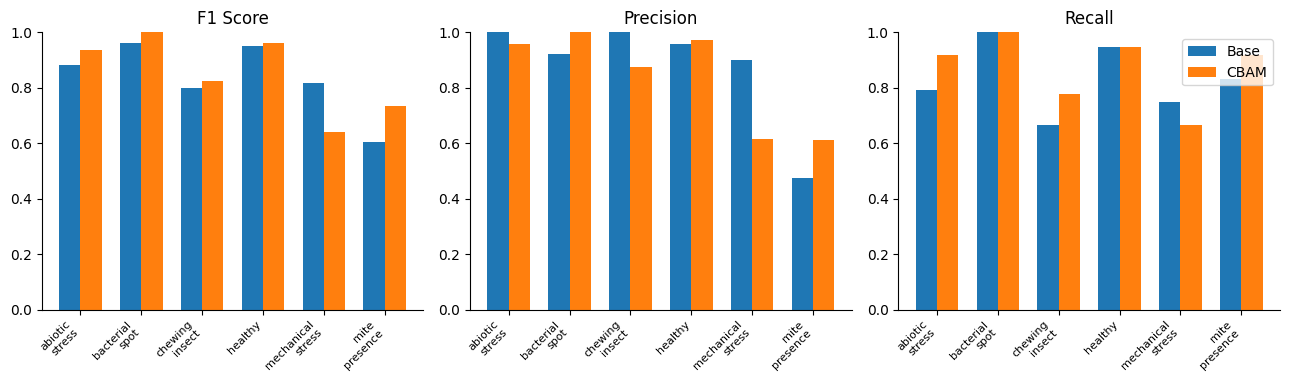


 CBAM vs Base comparison process completed.


In [4]:
def plot_and_save_comparison(metrics_dict, model_name, classes, out_dir):
    """Plots and saves the comparison of Base vs CBAM metrics for a given model."""
    colors = ["#1f77b4", "#ff7f0e"] 
    f1_base   = metrics_dict["base"]["f1"]
    f1_cbam   = metrics_dict["cbam"]["f1"]
    prec_base = metrics_dict["base"]["precision"]
    prec_cbam = metrics_dict["cbam"]["precision"]
    rec_base  = metrics_dict["base"]["recall"]
    rec_cbam  = metrics_dict["cbam"]["recall"]

    display_classes = [c.replace("_", "\n") for c in classes]

    x = np.arange(len(classes))
    width = 0.35

    fig, ax = plt.subplots(1, 3, figsize=(13, 4))
    fig.subplots_adjust(wspace=0.3)

    for axis, (base_vals, cbam_vals), title in zip(
        ax,
        [(f1_base, f1_cbam), (prec_base, prec_cbam), (rec_base, rec_cbam)],
        ["F1 Score", "Precision", "Recall"]
    ):
        axis.bar(x - width/2, base_vals, width, label="Base", color=colors[0])
        axis.bar(x + width/2, cbam_vals, width, label="CBAM", color=colors[1])
        axis.set_xticks(x)
        axis.set_xticklabels(display_classes, rotation=45, ha="right", fontsize=8)
        axis.set_ylim(0, 1)
        axis.set_title(title)

    ax[2].legend(loc="upper right")
    sns.despine()
    plt.tight_layout()

    out_path = out_dir / f"cbam_comparison_{model_name}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Plot saved in: {out_path}")
    plt.show()
    plt.close()


def print_metrics_table(metrics_dict, model_name, classes):
    """Prints a table of metrics by class (Base vs CBAM)."""
    print(f"\n📊 Metrics by class for {model_name}:\n")
    for variant in ["base", "cbam"]:
        print(f"--- {variant.upper()} ---")
        f1        = metrics_dict[variant]["f1"]
        precision = metrics_dict[variant]["precision"]
        recall    = metrics_dict[variant]["recall"]
        for i, cls in enumerate(classes):
            print(f"  {cls:<22}  F1={f1[i]:.4f}  Prec={precision[i]:.4f}  Rec={recall[i]:.4f}")
        print(f"\n  📌 Macro  F1={np.mean(f1):.4f}  Prec={np.mean(precision):.4f}  Rec={np.mean(recall):.4f}\n")


output_comparison = OUTPUT_DIR / "cbam_comparisons"
output_comparison.mkdir(parents=True, exist_ok=True)

print("Creating comparison plots...\n")

for model_name in TARGET_MODELS:
    print(f"{'='*45}")
    print(f"🧠 Modelo: {model_name}")
    print(f"{'='*45}")

    try:
        f1_b, rec_b, prec_b = extract_per_class_metrics(df_base, model_name)
        f1_c, rec_c, prec_c = extract_per_class_metrics(df_cbam, f"{model_name}_cbam")
    except (ValueError, KeyError) as e:
        print(f"⚠️  Error al extraer métricas: {e}")
        continue

    metrics_dict = {
        "base": {"f1": f1_b, "recall": rec_b, "precision": prec_b},
        "cbam": {"f1": f1_c, "recall": rec_c, "precision": prec_c},
    }

    print_metrics_table(metrics_dict, model_name, CLASSES)
    plot_and_save_comparison(metrics_dict, model_name, CLASSES, output_comparison)

print("\n CBAM vs Base comparison process completed.")

## EVALUATING BEFORE VS AFTER FT
Comparing F1 macro on local dataset before and after fine-tuning models.

In [16]:
def load_tl_csv(csv_path, model_col=COL_TL_MODEL):
    """Loads the TL CSV and normalizes the model name."""
    if not csv_path.exists():
        raise FileNotFoundError(f"No file found: {csv_path}")
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=[model_col])
    df[model_col] = df[model_col].str.strip().str.lower()
    return df


print("Loading TL CSVs...")
df_tl_base = load_tl_csv(TL_BASE_MODELS_CSV)
df_tl_cbam = load_tl_csv(TL_CBAM_MODELS_CSV)
df_tl_cbam = df_tl_cbam[df_tl_cbam["model"].isin(TARGET_MODELS)]
print(f"   TL Base models : {sorted(df_tl_base[COL_TL_MODEL].unique())}")
print(f"   TL CBAM models : {sorted(df_tl_cbam[COL_TL_MODEL].unique())}")

Loading TL CSVs...
   TL Base models : ['densenet121', 'efficientnetb0', 'efficientnetb3', 'efficientnetb5', 'inceptionv3', 'mobilenetv2', 'mobilenetv3large', 'resnet101', 'resnet50', 'vgg16', 'vgg19']
   TL CBAM models : ['efficientnetb3_cbam', 'efficientnetb5_cbam', 'inceptionv3_cbam']


Plotting Before vs After FT graph...

Comparison graph generated successfully.


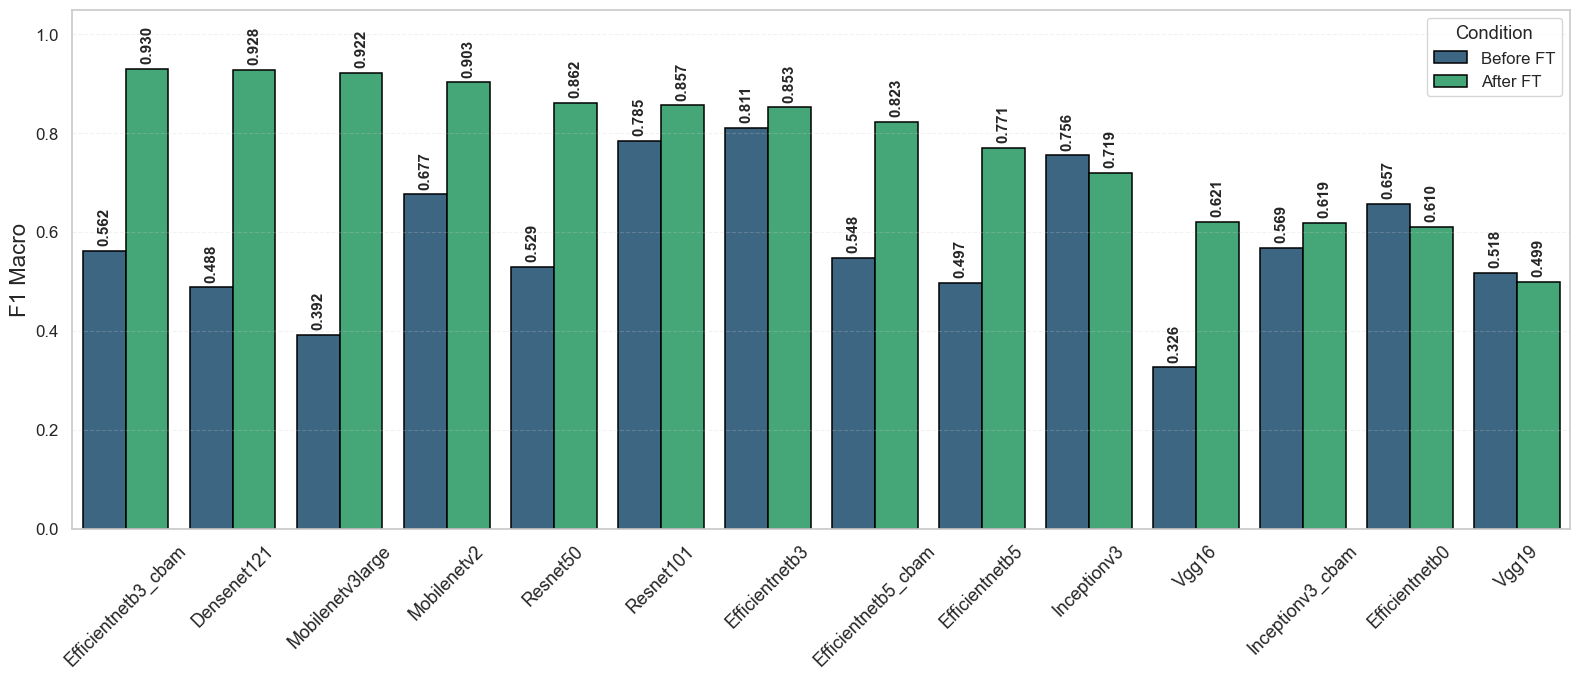

In [32]:
def build_before_after_df(
    df_base, df_cbam,
    model_col=COL_TL_MODEL,
    col_before=COL_TL_F1_BEFORE,
    col_after=COL_TL_F1_AFTER,
):
    """
    Joins the Base and CBAM DataFrames, adds a `Model_Type` column
    and a readable name label for plotting.
    It considers the best strategy per model (the one that maximizes F1_after).
    """
    def _best_per_model(df, type_label, col_after=col_after):
        df = df.copy()
        df["Model_Type"] = type_label
        df = df.sort_values(col_after, ascending=False).groupby(model_col).head(1)
        return df

    df_b = _best_per_model(df_base, "Base")
    df_c = _best_per_model(df_cbam, "CBAM")
    combined = pd.concat([df_b, df_c], ignore_index=True)

    def _format_name(row):
        name = str(row[model_col]).capitalize()
        # if row["Model_Type"] == "CBAM":
            
            # return f"{name} (CBAM)"
            # return name
        return name

    combined["Model_Plot"] = combined.apply(_format_name, axis=1)
    return combined


def plot_before_after_ft(
    df_combined,
    col_before=COL_TL_F1_BEFORE,
    col_after=COL_TL_F1_AFTER,
    out_dir=OUTPUT_DIR,
):
    """
    Generates the grouped bar chart for Before FT / After FT.
    """
    df_plot = pd.melt(
        df_combined,
        id_vars=["Model_Plot"],
        value_vars=[col_before, col_after],
        var_name="Condition",
        value_name="F1",
    )

    df_plot["Condition"] = df_plot["Condition"].replace({
        col_before: "Before FT",
        col_after:  "After FT",
    })

    order = (
        df_combined
        .sort_values(col_after, ascending=False)["Model_Plot"]
        .tolist()
    )

    sns.set_theme(style="whitegrid", font_scale=1.1)
    plt.figure(figsize=(16, 7))
    palette = sns.color_palette("viridis", 2)

    ax = sns.barplot(
        data=df_plot,
        x="Model_Plot", y="F1", hue="Condition",
        order=order,
        palette=palette,
        edgecolor="black",
        linewidth=1.1,
    )

    # --- GRID OVERLAY EFFECT ---
    ax.set_axisbelow(False)
    ax.grid(True, axis="y", linestyle="--", alpha=0.25, linewidth=0.8, zorder=10)
    ax.tick_params(axis="x", labelsize=13)
    ax.set_ylabel("F1 Macro", fontsize=16)
    plt.xticks(rotation=45, ha="center")
    # ensure bars stay under grid
    for patch in ax.patches:
        patch.set_zorder(2)

    plt.ylabel("F1 Macro")
    plt.xlabel("")
    plt.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
    plt.ylim(0, 1.05)

    # --- VALUE LABELS (bigger font) ---
    offset = 0.01
    for p in ax.patches:
        height = p.get_height()
        if abs(height) < 1e-6:
            continue
        ax.annotate(
            f"{height:.3f}",
            (p.get_x() + p.get_width() / 2, height + offset),
            ha="center",
            va="bottom",
            fontsize=11,   # 👈 increased
            rotation=90,
            fontweight="bold"
        )

    plt.tight_layout()


print("Plotting Before vs After FT graph...")
df_combined = build_before_after_df(df_tl_base, df_tl_cbam)
plot_before_after_ft(df_combined, out_dir=OUTPUT_DIR)
print("\nComparison graph generated successfully.")